# Analysis of FPV scenarios by comparing model output

Author: Sofia Midauar


Date: February 2025

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from osgeo import ogr # conda install gdal
import glob2 as glob
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

import seaborn as sns
import re
import calendar
import datetime
from scipy.optimize import curve_fit
from matplotlib.ticker import FuncFormatter

## Define functions

In [2]:
def is_fpv(x, y, polys):
    """Returns a boolean mask array representing the presence of FPV-covered grid points.
    `x` and `y` are 2D arrays with x and y coordinates.
    `polys` must be an iterable of osgeo.ogr.Geometry objects from a shapefile.
    """
    def is_in_polys(x, y):
        point = ogr.Geometry(ogr.wkbPoint)
        point.AddPoint(x, y)
        for poly in polys:
            if point.Within(poly):
                return True
        return False
    is_in_polys = np.vectorize(is_in_polys)
    return is_in_polys(x, y)

In [3]:
def create_fpv_mask(xcenters, ycenters, fpv_shp_file):
    """Returns a boolean mask array representing the presence of FPV-covered grid points.
     `xcenters` and `ycenters` are 2D arrays with x and y cell center coordinates. They can be obtained from XZ and XZ coordinates of a trim-*.nc file.
     `fpv_shp_file` is a path to a shapefile.
    """
    ds = ogr.Open(fpv_shp_file)
    layer = ds.GetLayer(0)
    polys = []
    for i in range(layer.GetFeatureCount()):
        feature = layer.GetFeature(i)
        geom = feature.geometry().Clone()
        polys.append(geom)

    return is_fpv(xcenters, ycenters, polys)

In [4]:
def season_of_date(date_UTC):
    """Returns season for given datetime"""
    year = str(pd.to_datetime(date_UTC.strftime('%Y-%m-%d')).year)
    seasons = {'spring': pd.date_range(start= pd.to_datetime(year +'-03-21'), end=pd.to_datetime(year + '-06-20')),
               'summer': pd.date_range(start= pd.to_datetime(year + '-06-21'), end= pd.to_datetime(year + '-09-22')),
               'autumn': pd.date_range(start= pd.to_datetime(year + '-09-23'), end= pd.to_datetime(year + '-12-20')),
               'winter': pd.date_range(start= pd.to_datetime(year + '-12-21'), end= pd.to_datetime(year + '-03-20'))}
    if (pd.to_datetime(year +'-03-21') <= date_UTC <= pd.to_datetime(year + '-06-20')):
        return 'spring'
    elif (pd.to_datetime(year +'-06-21') <= date_UTC <= pd.to_datetime(year + '-09-22')):
        return 'summer'
    elif (pd.to_datetime(year +'-09-23') <= date_UTC <= pd.to_datetime(year + '-12-20')):
        return 'autumn'
    else:
        return 'winter'

## Folder location

In [5]:
# Folder path for model output FPV scenarios
path_output = '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios/'

# Folder path for shapefiles of scenarios analysed
path_shapes = '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic/'

# Folder path for saving figures
path_figures = 'C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/figures_FPV/FPV_scenarios/'

## Read and process files

Note that constinuents (data variable R1) are indexed over M and N dimensions instead of MC and MC.

M, N are for **cell centers** (XZ, YZ).

MC, NC are for cell corners (XCOR, YCOR)

Thus, the coordinates to create the mask should be **XZ, YZ**.

In [6]:
# input trim files (model output)
trim_files = sorted(glob.glob(path_output + 'trim*.nc'))
trim_files

['//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_DONUT_notransition.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov05_10x10.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov10_10x10.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov10_10x20.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov10_20x20.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov20_10x10.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov37nogap.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov41nogap.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov43nogaps.nc',
 '//luna/fst/LEC/Users/midauarg/

In [7]:
# input shapefiles - FPV scenarios, should be consistent with trim output
# shapefiles = sorted(glob.glob(path_shapes + '*.shp'))[18:21]
# shapefiles = ['//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/lake_water_surface_right.shp', 
#               '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/lake_water_surface_right.shp', 
#               '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/lake_water_surface_right.shp', 
#               '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/lake_water_surface_right.shp', 
#               '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/lake_water_surface_right.shp'] # whole lake

shapefiles = ['//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp', 
              '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp', 
              '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp', 
              '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp', 
              '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp', 
              '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp', 
              '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp', 
              '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp', 
              '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp', 
              '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp', 
              '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp'] # array perimeter

# shapefiles = ['//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_02_cov10_donut_merge.shp',
#               '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_01_cov10_10x10_merge.shp',
#               '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_02_cov10_10x20_merge.shp',
#               '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_02_cov10_20x20_merge.shp',
#               '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp']

# shapefiles = ['//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_01_cov05_10x10_merge.shp',
#               '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_01_cov10_10x10_merge.shp',
#               '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_01_cov20_10x10_merge.shp',
#               '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_01_cov37nogap_merge.shp',
#               '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_01_cov41nogap_merge.shp',
#               '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_01_cov43nogap_merge.shp',
#              '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp']
shapefiles

['//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp',
 '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp',
 '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp',
 '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp',
 '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp',
 '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp',
 '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp',
 '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp',
 '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp',
 '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic\\fpv_real_compact_right.shp',


In [8]:
trim_files[0][78:-3]

'FPV_real_DONUT_notransition'

In [9]:
# read output files and create array with only data that is under the FPV
FPV_index_mask_dic = {}
temp_WT_FPVcells_dic = {}

for run in range(0,len(trim_files)):
    name = trim_files[run][78:-3] # gets the working file name (scenario)
    # this next line should be calling from the shapefiles list
    shpfile = shapefiles[run] # read from shapefiles
    ds = xr.open_dataset(trim_files[run])
    ds["DK_LYR"] = ds.S1 - ds.ZK_LYR # creates attribute with output depth
    mask = create_fpv_mask(ds.XZ, ds.YZ, shpfile)
    ind = np.argwhere(mask) # list of pairs (m,n) where mask is True
    FPV_index_mask_dic[name] = ind.copy() # saves index of FPV cells
    temp = ds[['R1', 'DK_LYR']].isel(LSTSCI = 0)
    temp_WT_FPVcells_dic[name] = temp.copy()

print(FPV_index_mask_dic.keys())
print(temp_WT_FPVcells_dic.keys())

dict_keys(['FPV_real_DONUT_notransition', 'FPV_real_cov05_10x10', 'FPV_real_cov10_10x10', 'FPV_real_cov10_10x20', 'FPV_real_cov10_20x20', 'FPV_real_cov20_10x10', 'FPV_real_cov37nogap', 'FPV_real_cov41nogap', 'FPV_real_cov43nogaps', 'FPV_real_nogaps', 'validation_fulldata_spatialmeteo'])
dict_keys(['FPV_real_DONUT_notransition', 'FPV_real_cov05_10x10', 'FPV_real_cov10_10x10', 'FPV_real_cov10_10x20', 'FPV_real_cov10_20x20', 'FPV_real_cov20_10x10', 'FPV_real_cov37nogap', 'FPV_real_cov41nogap', 'FPV_real_cov43nogaps', 'FPV_real_nogaps', 'validation_fulldata_spatialmeteo'])


**Now we mask and redefine the data array for simplicity.**

This new data array can be easily indexed along time or depth (`KMAXOUT_RESTR`). Dimension `NM_MASKED` is dummy: it is a flattened dimension from M and N indices where FPV was present. This dimension should **only** be used to compute metrics, e.g., mean, along it.

NaN denote missing values (e.g., vertical layer below lake bottom or unresolved depth).

## Temperature

In [10]:
# redefines data array
scenarios = list(temp_WT_FPVcells_dic.keys())
indexes = list(FPV_index_mask_dic.keys())

WT_FPVcells_dic = {}

for scen in range(0, len(scenarios)):
    temp = temp_WT_FPVcells_dic[scenarios[scen]].copy() # gets water temperature results for this scenario
    ind = FPV_index_mask_dic[indexes[scen]].copy() # gets grid cell id for all cells where FPV is true
    
    tempfpv = xr.DataArray(
        temp.R1.values[:, :, ind[:, 0], ind[:, 1]],
        dims=["time", "KMAXOUT_RESTR", "MN_MASKED"],
        coords={"time": temp.time.values},
    )
    tempfpv = tempfpv.where(tempfpv != -999, np.nan)
    tempfpv_dataset = tempfpv.to_dataset(name="R1")
    
    temp_depth = xr.DataArray(
        temp.DK_LYR.values[:, ind[:, 0], ind[:, 1], :],
        dims=["time", "MN_MASKED", "KMAXOUT_RESTR"],
        coords={"time": temp.time.values},
    ) 
    temp_depth_dataset = temp_depth.to_dataset(name="DK_LYR")

    temp_depth = xr.merge([tempfpv_dataset, temp_depth_dataset]) # xr file with both temperature and its corresponding depth
    
    WT_FPVcells_dic[scenarios[scen]] = temp_depth.copy()

WT_FPVcells_dic.keys()

dict_keys(['FPV_real_DONUT_notransition', 'FPV_real_cov05_10x10', 'FPV_real_cov10_10x10', 'FPV_real_cov10_10x20', 'FPV_real_cov10_20x20', 'FPV_real_cov20_10x10', 'FPV_real_cov37nogap', 'FPV_real_cov41nogap', 'FPV_real_cov43nogaps', 'FPV_real_nogaps', 'validation_fulldata_spatialmeteo'])

In [11]:
## Estimate mean over FPV covered area for each timestep and layer
depth_obs = [0.5, 1, 2, 3, 4, 5, 6, 7]
FPV_scenarios_list = list(WT_FPVcells_dic.keys())
FPV_WT_depths_dic = {}

for scen in range(0, len(FPV_scenarios_list)):
    tempfpv = WT_FPVcells_dic[FPV_scenarios_list[scen]].copy()
    tempfpv = tempfpv.mean(dim = "MN_MASKED") # DataArray.mean ignores NaN when computing the mean
    data_modelled = np.empty((len(tempfpv.time.values), 8))
    # calculates temperature per depth (matching measurements) for each timestep
    for i in range(len(tempfpv.time.values)):
        tempfpv_t = tempfpv.isel(time = i) # subsets for timestep analysed
        depth = tempfpv_t.DK_LYR.values # gets depth values of modelled temperature
        temp = tempfpv_t.R1.values # gets water temperature value
        time = tempfpv_t.time.values # gets timestep analysed
        temp = temp[depth > 0] # gets temperature values for depth > 0
        depth = depth[depth > 0] # gets depth values > 0
        f = interp1d(depth, temp, fill_value = "extrapolate") # creates function to interp WT values according to depth
        data_modelled[i, :] = f(depth_obs) # creates array with WT values per depth (matching measurements), for each timestep
    
    temporary = pd.DataFrame(data_modelled, index = tempfpv.time) # transforms xarray into dataframe, time as index 
    temporary.dropna(axis=1, how='all', inplace = True) # removes columns where all rows are nan (inactive layer)
    temporary['depth_averaged_WT'] = temporary.mean(axis=1)
    if scen == 0:
        FPV_av_compare = pd.DataFrame(temporary['depth_averaged_WT'])
        FPV_av_compare.rename(columns = {'depth_averaged_WT':('depth_av_WT' + FPV_scenarios_list[scen][4:])}, 
                              inplace = True)
    else:
        FPV_av_compare[('depth_av_WT' + FPV_scenarios_list[scen][4:])] = temporary['depth_averaged_WT']
    
    FPV_WT_depths_dic[FPV_scenarios_list[scen][4:]] = temporary.copy() # creates dic with dfs for each scenario WT output

print(FPV_WT_depths_dic.keys())
FPV_av_compare.head(2)

dict_keys(['real_DONUT_notransition', 'real_cov05_10x10', 'real_cov10_10x10', 'real_cov10_10x20', 'real_cov10_20x20', 'real_cov20_10x10', 'real_cov37nogap', 'real_cov41nogap', 'real_cov43nogaps', 'real_nogaps', 'dation_fulldata_spatialmeteo'])


,depth_av_WTreal_DONUT_notransition,depth_av_WTreal_cov05_10x10,depth_av_WTreal_cov10_10x10,depth_av_WTreal_cov10_10x20,depth_av_WTreal_cov10_20x20,depth_av_WTreal_cov20_10x10,depth_av_WTreal_cov37nogap,depth_av_WTreal_cov41nogap,depth_av_WTreal_cov43nogaps,depth_av_WTreal_nogaps,depth_av_WTdation_fulldata_spatialmeteo
2022-09-09 00:00:00,25.235546,25.235546,25.235546,25.235546,25.235546,25.235546,25.235546,25.235546,25.235546,25.235546,25.235546
2022-09-09 06:00:00,25.065467,25.065562,25.065422,25.065425,25.065423,25.065178,25.065145,25.065467,25.065600,25.065753,25.062675


In [37]:
FPV_av_compare.to_csv('FPV_av_compare_perdepth_arrayperim.csv')

In [12]:
# FPV_av_compare.to_csv('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/summary_data/FPV_depthav_WT_compare_arrayperimeter.csv')

In [13]:
FPV_deltaWT_depths_dic = {}

scenarios = list(FPV_WT_depths_dic.keys())
base_noFPV = FPV_WT_depths_dic['dation_fulldata_spatialmeteo'].copy()

for scen in range(len(scenarios)-1):
    temp = FPV_WT_depths_dic[scenarios[scen]].copy()
    for col in range(len(temp.columns)):
        temp[('delta_depth' + str(temp.columns[col]))] = (temp[temp.columns[col]] - base_noFPV[base_noFPV.columns[col]])
    
    name = scenarios[scen]
    FPV_deltaWT_depths_dic[('delta_' + name)] = temp[temp.columns[9:]].copy()
    
FPV_deltaWT_depths_dic.keys()

dict_keys(['delta_real_DONUT_notransition', 'delta_real_cov05_10x10', 'delta_real_cov10_10x10', 'delta_real_cov10_10x20', 'delta_real_cov10_20x20', 'delta_real_cov20_10x10', 'delta_real_cov37nogap', 'delta_real_cov41nogap', 'delta_real_cov43nogaps', 'delta_real_nogaps'])

In [36]:
FPV_deltaWT_depths_dic['delta_real_DONUT_notransition'].to_csv('delta_real_DONUT_perdepth_arrayperim.csv')

In [14]:
# creates new df with only surface layer (0.5m depth) data
scenarios = list(FPV_deltaWT_depths_dic.keys())

for scen in range(len(scenarios)):
    temp = FPV_deltaWT_depths_dic[scenarios[scen]].copy()
    temp_df = pd.DataFrame(temp[temp.columns[0]])
    temp_df.index.name = 'time'
    temp_df.rename(columns = {temp_df.columns[0]:('0.5m_' + scenarios[scen][11:])}, inplace = True)
    
    if scen == 0:
        FPV_deltaWT_surface = temp_df.copy()
    else:
        FPV_deltaWT_surface = pd.merge(FPV_deltaWT_surface, temp_df, on = 'time')
        
FPV_deltaWT_surface.head(2)

,0.5m_DONUT_notransition,0.5m_cov05_10x10,0.5m_cov10_10x10,0.5m_cov10_10x20,0.5m_cov10_20x20,0.5m_cov20_10x10,0.5m_cov37nogap,0.5m_cov41nogap,0.5m_cov43nogaps,0.5m_nogaps
time,,,,,,,,,,
2022-09-09 00:00:00,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-09-09 06:00:00,0.004032,0.00414,0.004123,0.004411,0.004051,0.003898,0.003429,0.003971,0.004202,0.004955


In [15]:
# creates new df with only bottom layer (7m deep) data
scenarios = list(FPV_deltaWT_depths_dic.keys())

for scen in range(len(scenarios)):
    temp = FPV_deltaWT_depths_dic[scenarios[scen]].copy()
    temp_df = pd.DataFrame(temp[temp.columns[-2]])
    temp_df.index.name = 'time'
    temp_df.rename(columns = {temp_df.columns[0]:('7m_' + scenarios[scen][11:])}, inplace = True)
    
    if scen == 0:
        FPV_deltaWT_bottom = temp_df.copy()
    else:
        FPV_deltaWT_bottom = pd.merge(FPV_deltaWT_bottom, temp_df, on = 'time')
        
FPV_deltaWT_bottom.head(2)

,7m_DONUT_notransition,7m_cov05_10x10,7m_cov10_10x10,7m_cov10_10x20,7m_cov10_20x20,7m_cov20_10x10,7m_cov37nogap,7m_cov41nogap,7m_cov43nogaps,7m_nogaps
time,,,,,,,,,,
2022-09-09 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2022-09-09 06:00:00,-0.000328,-0.000349,-0.000353,-0.000398,-0.000357,-0.000368,-0.000286,-0.000339,-0.000348,-0.000428


In [16]:
# creates df with difference among scenarios
scenarios = list(FPV_deltaWT_depths_dic.keys())

for scen in range(len(scenarios)):
    temp = FPV_deltaWT_depths_dic[scenarios[scen]].copy()
    temp = pd.DataFrame(temp[temp.columns[-2]])
    temp.rename(columns = {temp.columns[0]:scenarios[scen]}, inplace = True)
    temp.index.name = 'time'
    
    if scen == 0:
        FPV_deltaWT_avdepth = temp.copy()
    else:
        FPV_deltaWT_avdepth = FPV_deltaWT_avdepth.join(temp)

FPV_deltaWT_avdepth = FPV_deltaWT_avdepth.loc['2022-10-01 00:00:00':]
FPV_deltaWT_avdepth.head(2)

,delta_real_DONUT_notransition,delta_real_cov05_10x10,delta_real_cov10_10x10,delta_real_cov10_10x20,delta_real_cov10_20x20,delta_real_cov20_10x10,delta_real_cov37nogap,delta_real_cov41nogap,delta_real_cov43nogaps,delta_real_nogaps
time,,,,,,,,,,
2022-10-01 00:00:00,-0.466194,-0.487110,-0.460003,-0.467997,-0.464516,-0.419604,-0.411966,-0.463437,-0.492670,-0.518801
2022-10-01 06:00:00,-0.448383,-0.468315,-0.442160,-0.449874,-0.446544,-0.403261,-0.395877,-0.445327,-0.473522,-0.498857


In [112]:
FPV_deltaWT_avdepth.to_csv('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/summary_data/FPV_deltaWT_avdepth_arrayperim.csv')

In [17]:
FPV_av_compare.to_csv('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/data_stats/FPV_av_compare_arrayperim_all.csv')
FPV_deltaWT_surface.to_csv('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/data_stats/FPV_deltaWT_surface_arrayperim_all.csv')
FPV_deltaWT_bottom.to_csv('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/data_stats/FPV_deltaWT_bottom_arrayperim_all.csv')
FPV_deltaWT_avdepth.to_csv('C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/data_stats/FPV_deltaWT_avdepth_arrayperim_all.csv')


### Prepare data for boxplots

In [17]:
scenarios = list(FPV_WT_depths_dic.keys())
scenarios

['real_DONUT_notransition',
 'real_cov05_10x10',
 'real_cov10_10x10',
 'real_cov10_10x20',
 'real_cov10_20x20',
 'real_cov20_10x10',
 'real_cov37nogap',
 'real_cov41nogap',
 'real_cov43nogaps',
 'real_nogaps',
 'dation_fulldata_spatialmeteo']

In [18]:
## DATAFRAME FOR CREATING BOXPLOTS
ndepths = 9 # number of model output time series per depth
scenarios = list(FPV_WT_depths_dic.keys())

# labels = ['37%', '41%', '43%', '46%', 'No FPV']

# labels = ['41% FPV - 80x80m', '41% FPV - 10x10m', 
#           '41% FPV - 10x20m', '41% FPV - 20x20m', 'No FPV']

# labels = ['43% FPV - 5% gaps', '41% FPV - 10% gaps','37% FPV - 20% gaps', 
#           '37% FPV - no gaps', '41% FPV - no gaps', '43% FPV - no gaps', 'No FPV']

labels = ['41% FPV - 10% gaps 80x80m', '43% FPV - 5% gaps 10x10m','41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m',
          '41% FPV - 10% gaps 20x20m', '37% FPV - 20% gaps 10x10m', '37% FPV - no gaps', '41% FPV - no gaps',
          '43% FPV - no gaps', '46% FPV - no gaps', 'No FPV']

for scen in range(len(scenarios)):
    temp_scenariodf = FPV_WT_depths_dic[scenarios[scen]].copy()
    for depth in range(0,ndepths,1):
        temporary = pd.DataFrame(temp_scenariodf[temp_scenariodf.columns[depth]])
        temporary.reset_index(inplace = True)
        temporary.rename(columns = {temporary.columns[0]:'time', temporary.columns[1]:'WT'}, inplace = True)
        temporary['depth'] = temp_scenariodf.columns[depth]
        temporary['scenario'] = labels[scen]
        # Join result to dataframe with control run output for comparison
        if (depth == 0) & (scen == 0):
            bp_WT_comp_depths = temporary.copy()
        else:
            bp_WT_comp_depths = pd.concat([bp_WT_comp_depths, temporary])

bp_WT_comp_depths['time'] = pd.to_datetime(bp_WT_comp_depths['time'])
bp_WT_comp_depths.set_index('time', inplace = True)
# Creates columns with month
bp_WT_comp_depths['month'] = bp_WT_comp_depths.index.month
bp_WT_comp_depths['year'] = bp_WT_comp_depths.index.year
bp_WT_comp_depths['year'] = bp_WT_comp_depths['year'].apply(lambda x: str(x)[2:])
bp_WT_comp_depths['month_str'] = ((bp_WT_comp_depths['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                  (bp_WT_comp_depths['year']))
bp_WT_comp_depths.reset_index(drop = True, inplace = True)
bp_WT_comp_depths.head(2)

,WT,depth,scenario,month,year,month_str
0,25.645320,0,41% FPV - 10% gaps 80x80m,9,22,Sep22
1,25.189326,0,41% FPV - 10% gaps 80x80m,9,22,Sep22


In [19]:
list(FPV_deltaWT_depths_dic.keys())

['delta_real_DONUT_notransition',
 'delta_real_cov05_10x10',
 'delta_real_cov10_10x10',
 'delta_real_cov10_10x20',
 'delta_real_cov10_20x20',
 'delta_real_cov20_10x10',
 'delta_real_cov37nogap',
 'delta_real_cov41nogap',
 'delta_real_cov43nogaps',
 'delta_real_nogaps']

In [20]:
## DATAFRAME FOR CREATING BOXPLOTS
ndepths = 9 # number of model output time series per depth
scenarios = list(FPV_deltaWT_depths_dic.keys())

# labels = ['37%', '41%', '43%', '46%']

# labels = ['41% FPV - 80x80m', '41% FPV - 10x10m', 
#           '41% FPV - 10x20m', '41% FPV - 20x20m']

# labels = ['43% FPV - 5% gaps', '41% FPV - 10% gaps','37% FPV - 20% gaps', 
#           '37% FPV - no gaps', '41% FPV - no gaps', '43% FPV - no gaps']

labels = ['41% FPV - 10% gaps 80x80m', '43% FPV - 5% gaps 10x10m','41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m',
          '41% FPV - 10% gaps 20x20m', '37% FPV - 20% gaps 10x10m', '37% FPV - no gaps', '41% FPV - no gaps',
          '43% FPV - no gaps', '46% FPV - no gaps']

for scen in range(len(scenarios)):
    tempWTdelta_scenariodf = FPV_deltaWT_depths_dic[scenarios[scen]].copy()
    for depth in range(0,ndepths,1):
        temporary = pd.DataFrame(tempWTdelta_scenariodf[tempWTdelta_scenariodf.columns[depth]])
        temporary.reset_index(inplace = True)
        temporary.rename(columns = {temporary.columns[0]:'time', temporary.columns[1]:'deltaWT'}, inplace = True)
        temporary['depth'] = tempWTdelta_scenariodf.columns[depth]
        temporary['scenario'] = labels[scen]
        # Join result to dataframe with control run output for comparison
        if (depth == 0) & (scen == 0):
            bp_deltaWT_comp_depths = temporary.copy()
        else:
            bp_deltaWT_comp_depths = pd.concat([bp_deltaWT_comp_depths, temporary])

bp_deltaWT_comp_depths['time'] = pd.to_datetime(bp_deltaWT_comp_depths['time'])
bp_deltaWT_comp_depths.set_index('time', inplace = True)
# Creates columns with month
bp_deltaWT_comp_depths['month'] = bp_deltaWT_comp_depths.index.month
bp_deltaWT_comp_depths['year'] = bp_deltaWT_comp_depths.index.year
bp_deltaWT_comp_depths['year'] = bp_deltaWT_comp_depths['year'].apply(lambda x: str(x)[2:])
bp_deltaWT_comp_depths['month_str'] = ((bp_deltaWT_comp_depths['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                       (bp_deltaWT_comp_depths['year']))
bp_deltaWT_comp_depths.reset_index(drop = True, inplace = True)
bp_deltaWT_comp_depths.head(2)

,deltaWT,depth,scenario,month,year,month_str
0,0.000000,delta_depth0,41% FPV - 10% gaps 80x80m,9,22,Sep22
1,0.004032,delta_depth0,41% FPV - 10% gaps 80x80m,9,22,Sep22


In [21]:
list(FPV_WT_depths_dic.keys())

['real_DONUT_notransition',
 'real_cov05_10x10',
 'real_cov10_10x10',
 'real_cov10_10x20',
 'real_cov10_20x20',
 'real_cov20_10x10',
 'real_cov37nogap',
 'real_cov41nogap',
 'real_cov43nogaps',
 'real_nogaps',
 'dation_fulldata_spatialmeteo']

In [22]:
## DATAFRAME FOR CREATING BOXPLOTS - depth averaged water temperature
scenarios = list(FPV_WT_depths_dic.keys())

# labels = ['37%', '41%', '43%', '46%', 'No FPV']

# labels = ['41% FPV - 80x80m', '41% FPV - 10x10m', 
#           '41% FPV - 10x20m', '41% FPV - 20x20m', 'No FPV']

# labels = ['43% FPV - 5% gaps', '41% FPV - 10% gaps','37% FPV - 20% gaps', 
#           '37% FPV - no gaps', '41% FPV - no gaps', '43% FPV - no gaps', 'No FPV']

labels = ['41% FPV - 10% gaps 80x80m', '43% FPV - 5% gaps 10x10m','41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m',
          '41% FPV - 10% gaps 20x20m', '37% FPV - 20% gaps 10x10m', '37% FPV - no gaps', '41% FPV - no gaps',
          '43% FPV - no gaps', '46% FPV - no gaps', 'No FPV']

for scen in range(len(scenarios)):
    temp_avdepth = FPV_WT_depths_dic[scenarios[scen]].copy()
    temp_avdepth = temp_avdepth[['depth_averaged_WT']]
    temp_avdepth['scenario'] = labels[scen]
    # Join result to dataframe with control run output for comparison
    if scen == 0:
        bp_WT_comp_average = temp_avdepth.copy()
    else:
        bp_WT_comp_average = pd.concat([bp_WT_comp_average, temp_avdepth])

# Creates columns with month
bp_WT_comp_average['month'] = bp_WT_comp_average.index.month
bp_WT_comp_average['year'] = bp_WT_comp_average.index.year
bp_WT_comp_average['year'] = bp_WT_comp_average['year'].apply(lambda x: str(x)[2:])
bp_WT_comp_average['month_str'] = ((bp_WT_comp_average['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                   (bp_WT_comp_average['year']))
bp_WT_comp_average.reset_index(drop = True, inplace = True)
bp_WT_comp_average.head(2)

,depth_averaged_WT,scenario,month,year,month_str
0,25.235546,41% FPV - 10% gaps 80x80m,9,22,Sep22
1,25.065467,41% FPV - 10% gaps 80x80m,9,22,Sep22


In [23]:
list(FPV_deltaWT_avdepth.columns)

['delta_real_DONUT_notransition',
 'delta_real_cov05_10x10',
 'delta_real_cov10_10x10',
 'delta_real_cov10_10x20',
 'delta_real_cov10_20x20',
 'delta_real_cov20_10x10',
 'delta_real_cov37nogap',
 'delta_real_cov41nogap',
 'delta_real_cov43nogaps',
 'delta_real_nogaps']

In [24]:
## DATAFRAME FOR CREATING BOXPLOTS - depth averaged water temperature
scenarios = list(FPV_deltaWT_avdepth.columns)

# labels = ['37%', '41%', '43%', '46%']

# labels = ['41% FPV - 80x80m', '41% FPV - 10x10m', 
#           '41% FPV - 10x20m', '41% FPV - 20x20m']

# labels = ['43% FPV - 5% gaps', '41% FPV - 10% gaps','37% FPV - 20% gaps', 
#           '37% FPV - no gaps', '41% FPV - no gaps', '43% FPV - no gaps']

labels = ['41% FPV - 10% gaps 80x80m', '43% FPV - 5% gaps 10x10m','41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m',
          '41% FPV - 10% gaps 20x20m', '37% FPV - 20% gaps 10x10m', '37% FPV - no gaps', '41% FPV - no gaps',
          '43% FPV - no gaps', '46% FPV - no gaps']

for scen in range(len(scenarios)):
    temp_avdepth_delta = pd.DataFrame(FPV_deltaWT_avdepth[FPV_deltaWT_avdepth.columns[scen]]).copy()
    temp_avdepth_delta.columns = ['depth_averaged_deltaWT']
    temp_avdepth_delta['scenario'] = labels[scen]
    temp_avdepth_delta.index.name = 'time'
    
    # Join result to dataframe with control run output for comparison
    if scen == 0:
        bp_deltaWT_comp_av = temp_avdepth_delta.copy()
    else:
        bp_deltaWT_comp_av = pd.concat([bp_deltaWT_comp_av, temp_avdepth_delta])

# Creates columns with month
bp_deltaWT_comp_av['hour'] = bp_deltaWT_comp_av.index.hour
bp_deltaWT_comp_av['month'] = bp_deltaWT_comp_av.index.month
bp_deltaWT_comp_av['year'] = bp_deltaWT_comp_av.index.year
bp_deltaWT_comp_av['year'] = bp_deltaWT_comp_av['year'].apply(lambda x: str(x)[2:])
bp_deltaWT_comp_av['month_str'] = ((bp_deltaWT_comp_av['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                   (bp_deltaWT_comp_av['year']))
bp_deltaWT_comp_av.reset_index(drop = False, inplace = True)
bp_deltaWT_comp_av['season'] = bp_deltaWT_comp_av['time'].apply(season_of_date)
bp_deltaWT_comp_av.head(2)

,time,depth_averaged_deltaWT,scenario,hour,month,year,month_str,season
0,2022-10-01 00:00:00,-0.466194,41% FPV - 10% gaps 80x80m,0,10,22,Oct22,autumn
1,2022-10-01 06:00:00,-0.448383,41% FPV - 10% gaps 80x80m,6,10,22,Oct22,autumn


In [25]:
# subsets for 18h data only
bp_deltaWT_comp_av_18h = bp_deltaWT_comp_av[bp_deltaWT_comp_av['hour'] == 18]
bp_deltaWT_comp_av_18h.head(2)

,time,depth_averaged_deltaWT,scenario,hour,month,year,month_str,season
3,2022-10-01 18:00:00,-0.454108,41% FPV - 10% gaps 80x80m,18,10,22,Oct22,autumn
7,2022-10-02 18:00:00,-0.476655,41% FPV - 10% gaps 80x80m,18,10,22,Oct22,autumn


In [26]:
# subsets for 6am data only
bp_deltaWT_comp_av_6am = bp_deltaWT_comp_av[bp_deltaWT_comp_av['hour'] == 6]
bp_deltaWT_comp_av_6am.head(2)

,time,depth_averaged_deltaWT,scenario,hour,month,year,month_str,season
1,2022-10-01 06:00:00,-0.448383,41% FPV - 10% gaps 80x80m,6,10,22,Oct22,autumn
5,2022-10-02 06:00:00,-0.453549,41% FPV - 10% gaps 80x80m,6,10,22,Oct22,autumn


In [27]:
list(FPV_deltaWT_surface.columns)

['0.5m_DONUT_notransition',
 '0.5m_cov05_10x10',
 '0.5m_cov10_10x10',
 '0.5m_cov10_10x20',
 '0.5m_cov10_20x20',
 '0.5m_cov20_10x10',
 '0.5m_cov37nogap',
 '0.5m_cov41nogap',
 '0.5m_cov43nogaps',
 '0.5m_nogaps']

In [28]:
## DATAFRAME FOR CREATING BOXPLOTS - surface water temperature
scenarios = list(FPV_deltaWT_surface.columns)

# labels = ['37%', '41%', '43%', '46%']

# labels = ['41% FPV - 80x80m', '41% FPV - 10x10m', 
#           '41% FPV - 10x20m', '41% FPV - 20x20m']

# labels = ['43% FPV - 5% gaps', '41% FPV - 10% gaps','37% FPV - 20% gaps', 
#           '37% FPV - no gaps', '41% FPV - no gaps', '43% FPV - no gaps']

labels = ['41% FPV - 10% gaps 80x80m', '43% FPV - 5% gaps 10x10m','41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m',
          '41% FPV - 10% gaps 20x20m', '37% FPV - 20% gaps 10x10m', '37% FPV - no gaps', '41% FPV - no gaps',
          '43% FPV - no gaps', '46% FPV - no gaps']

for scen in range(len(scenarios)):
    temp_surface_delta = pd.DataFrame(FPV_deltaWT_surface[FPV_deltaWT_surface.columns[scen]]).copy()
    temp_surface_delta.columns = ['surface_deltaWT']
    temp_surface_delta['scenario'] = labels[scen]
    # Join result to dataframe with control run output for comparison
    if scen == 0:
        bp_deltaWT_comp_surf = temp_surface_delta.copy()
    else:
        bp_deltaWT_comp_surf = pd.concat([bp_deltaWT_comp_surf, temp_surface_delta])

# Creates columns with month
bp_deltaWT_comp_surf['hour'] = bp_deltaWT_comp_surf.index.hour
bp_deltaWT_comp_surf['month'] = bp_deltaWT_comp_surf.index.month
bp_deltaWT_comp_surf['year'] = bp_deltaWT_comp_surf.index.year
bp_deltaWT_comp_surf['year'] = bp_deltaWT_comp_surf['year'].apply(lambda x: str(x)[2:])
bp_deltaWT_comp_surf['month_str'] = ((bp_deltaWT_comp_surf['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                     (bp_deltaWT_comp_surf['year']))
bp_deltaWT_comp_surf.reset_index(drop = False, inplace = True)
bp_deltaWT_comp_surf['season'] = bp_deltaWT_comp_surf['time'].apply(season_of_date)
bp_deltaWT_comp_surf.head(2)

,time,surface_deltaWT,scenario,hour,month,year,month_str,season
0,2022-09-09 00:00:00,0.000000,41% FPV - 10% gaps 80x80m,0,9,22,Sep22,summer
1,2022-09-09 06:00:00,0.004032,41% FPV - 10% gaps 80x80m,6,9,22,Sep22,summer


In [29]:
list(FPV_deltaWT_bottom.columns)

['7m_DONUT_notransition',
 '7m_cov05_10x10',
 '7m_cov10_10x10',
 '7m_cov10_10x20',
 '7m_cov10_20x20',
 '7m_cov20_10x10',
 '7m_cov37nogap',
 '7m_cov41nogap',
 '7m_cov43nogaps',
 '7m_nogaps']

In [30]:
## DATAFRAME FOR CREATING BOXPLOTS - surface water temperature
scenarios = list(FPV_deltaWT_bottom.columns)

# labels = ['37%', '41%', '43%', '46%']

# labels = ['41% FPV - 80x80m', '41% FPV - 10x10m', 
#           '41% FPV - 10x20m', '41% FPV - 20x20m']

# labels = ['43% FPV - 5% gaps', '41% FPV - 10% gaps','37% FPV - 20% gaps', 
#           '37% FPV - no gaps', '41% FPV - no gaps', '43% FPV - no gaps', 'No FPV']

labels = ['41% FPV - 10% gaps 80x80m', '43% FPV - 5% gaps 10x10m','41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m',
          '41% FPV - 10% gaps 20x20m', '37% FPV - 20% gaps 10x10m', '37% FPV - no gaps', '41% FPV - no gaps',
          '43% FPV - no gaps', '46% FPV - no gaps']

for scen in range(len(scenarios)):
    temp_bottom_delta = pd.DataFrame(FPV_deltaWT_bottom[FPV_deltaWT_bottom.columns[scen]]).copy()
    temp_bottom_delta.columns = ['bottom_deltaWT']
    temp_bottom_delta['scenario'] = labels[scen]
    # Join result to dataframe with control run output for comparison
    if scen == 0:
        bp_deltaWT_comp_bottom = temp_bottom_delta.copy()
    else:
        bp_deltaWT_comp_bottom = pd.concat([bp_deltaWT_comp_bottom, temp_bottom_delta])

# Creates columns with month
bp_deltaWT_comp_bottom['hour'] = bp_deltaWT_comp_bottom.index.hour
bp_deltaWT_comp_bottom['month'] = bp_deltaWT_comp_bottom.index.month
bp_deltaWT_comp_bottom['year'] = bp_deltaWT_comp_bottom.index.year
bp_deltaWT_comp_bottom['year'] = bp_deltaWT_comp_bottom['year'].apply(lambda x: str(x)[2:])
bp_deltaWT_comp_bottom['month_str'] = ((bp_deltaWT_comp_bottom['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                       (bp_deltaWT_comp_bottom['year']))
bp_deltaWT_comp_bottom.reset_index(drop = False, inplace = True)
bp_deltaWT_comp_bottom['season'] = bp_deltaWT_comp_bottom['time'].apply(season_of_date)
bp_deltaWT_comp_bottom.head(2)

,time,bottom_deltaWT,scenario,hour,month,year,month_str,season
0,2022-09-09 00:00:00,0.000000,41% FPV - 10% gaps 80x80m,0,9,22,Sep22,summer
1,2022-09-09 06:00:00,-0.000328,41% FPV - 10% gaps 80x80m,6,9,22,Sep22,summer


# Summary of data

In [31]:
# creates column with season info
FPV_deltaWT_avdepth_season = FPV_deltaWT_avdepth.copy()
FPV_deltaWT_avdepth_season.reset_index(drop = False, inplace = True)
FPV_deltaWT_avdepth_season['season'] = FPV_deltaWT_avdepth_season['time'].apply(season_of_date)
FPV_deltaWT_avdepth_season.set_index('time', inplace = True)
FPV_deltaWT_avdepth_season.head(2)

,delta_real_DONUT_notransition,delta_real_cov05_10x10,delta_real_cov10_10x10,delta_real_cov10_10x20,delta_real_cov10_20x20,delta_real_cov20_10x10,delta_real_cov37nogap,delta_real_cov41nogap,delta_real_cov43nogaps,delta_real_nogaps,season
time,,,,,,,,,,,
2022-10-01 00:00:00,-0.466194,-0.487110,-0.460003,-0.467997,-0.464516,-0.419604,-0.411966,-0.463437,-0.492670,-0.518801,autumn
2022-10-01 06:00:00,-0.448383,-0.468315,-0.442160,-0.449874,-0.446544,-0.403261,-0.395877,-0.445327,-0.473522,-0.498857,autumn


In [32]:
# creates column with season info for surface layer
FPV_deltaWT_season = FPV_deltaWT_surface.copy()
FPV_deltaWT_season.reset_index(drop = False, inplace = True)
FPV_deltaWT_season['season'] = FPV_deltaWT_season['time'].apply(season_of_date)
FPV_deltaWT_season.set_index('time', inplace = True)
FPV_deltaWT_season.head(2)

,0.5m_DONUT_notransition,0.5m_cov05_10x10,0.5m_cov10_10x10,0.5m_cov10_10x20,0.5m_cov10_20x20,0.5m_cov20_10x10,0.5m_cov37nogap,0.5m_cov41nogap,0.5m_cov43nogaps,0.5m_nogaps,season
time,,,,,,,,,,,
2022-09-09 00:00:00,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,summer
2022-09-09 06:00:00,0.004032,0.00414,0.004123,0.004411,0.004051,0.003898,0.003429,0.003971,0.004202,0.004955,summer


In [47]:
# FPV 01
spring_summer = FPV_deltaWT_avdepth_season[(FPV_deltaWT_avdepth_season['season'] == 'spring') | 
                                           (FPV_deltaWT_avdepth_season['season'] == 'summer')]

spring_summer_surf = FPV_deltaWT_season[(FPV_deltaWT_season['season'] == 'spring') | 
                                        (FPV_deltaWT_season['season'] == 'summer')] # surface layer

describe_01 = spring_summer.describe()
describe_01 = describe_01[['delta_real_nogaps', 'delta_real_cov43nogaps',
                           'delta_real_cov41nogap', 'delta_real_cov37nogap']]

describe_01.columns = ['46% FPV\nno gaps', '43% FPV\nno gaps', 
                       '41% FPV\nno gaps','37% FPV\nno gaps']
describe_01_t = describe_01.T
describe_01_t = describe_01_t[describe_01_t.columns[1:]]

# same for surface layer
describe_surf_01 = spring_summer_surf.describe()
describe_surf_01 = describe_surf_01[['0.5m_nogaps', '0.5m_cov43nogaps',
                                     '0.5m_cov41nogap', '0.5m_cov37nogap']]

describe_surf_01.columns = ['46% FPV\nno gaps', '43% FPV\nno gaps', 
                            '41% FPV\nno gaps','37% FPV\nno gaps']
describe_surf_01_t = describe_surf_01.T
describe_surf_01_t = describe_surf_01_t[describe_surf_01_t.columns[1:]]

describe_surf_01.head(2)

,46% FPV\nno gaps,43% FPV\nno gaps,41% FPV\nno gaps,37% FPV\nno gaps
count,791.000000,791.000000,791.000000,791.000000
mean,-1.458799,-1.385795,-1.300449,-1.152556


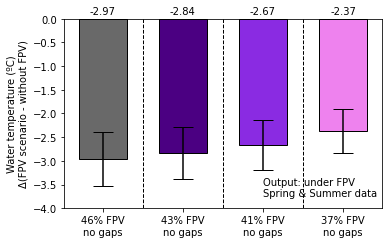

In [36]:
# Get mean and std
means = describe_01.loc['mean']
stds = describe_01.loc['std']

# Define your custom colors
custom_colors = {
    '46% FPV\nno gaps': 'dimgray',
    '43% FPV\nno gaps': 'indigo',
    '41% FPV\nno gaps': 'blueviolet',
    '37% FPV\nno gaps': 'violet',
}

# Extract the colors in the same order as the columns
colors = [custom_colors[col] for col in means.index]

# Plot
fig, ax = plt.subplots(figsize=(5.5, 3.5))

bars = ax.bar(
    means.index,
    means.values,
    yerr=stds.values,
    capsize=10,
    color=[custom_colors[col] for col in means.index],
    edgecolor='black',
    width = 0.6
)

# Apply hatches and add value labels
for bar, col in zip(bars, means.index):
    # Add text on top of the bar
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # center of the bar
        0.05,             # just above error bar
        f'{height:.2f}',                    # formatted mean
        ha='center', va='bottom', fontsize=10
    )

ax.text(2, -3.75, 'Output: under FPV\nSpring & Summer data', color = 'k', fontsize = 10)

ax.set_ylim(-4, 0)

plt.axvline(x = 0.5, color='k', linestyle='--', linewidth=1)
plt.axvline(x = 1.5, color='k', linestyle='--', linewidth=1)
plt.axvline(x = 2.5, color='k', linestyle='--', linewidth=1)

# Add labels and title
plt.ylabel(u'Water temperature (ºC)\nΔ(FPV scenario - without FPV)')
plt.tight_layout()
# plt.savefig('FPV01_arrayperim_describe_barplot.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

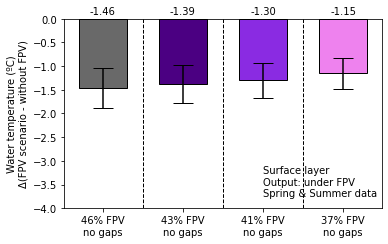

In [48]:
# -------- SURFACE LAYER ---------
# Get mean and std
means = describe_surf_01.loc['mean']
stds = describe_surf_01.loc['std']

# Define your custom colors
custom_colors = {
    '46% FPV\nno gaps': 'dimgray',
    '43% FPV\nno gaps': 'indigo',
    '41% FPV\nno gaps': 'blueviolet',
    '37% FPV\nno gaps': 'violet',
}

# Extract the colors in the same order as the columns
colors = [custom_colors[col] for col in means.index]

# Plot
fig, ax = plt.subplots(figsize=(5.5, 3.5))

bars = ax.bar(
    means.index,
    means.values,
    yerr=stds.values,
    capsize=10,
    color=[custom_colors[col] for col in means.index],
    edgecolor='black',
    width = 0.6
)

# Apply hatches and add value labels
for bar, col in zip(bars, means.index):
    # Add text on top of the bar
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # center of the bar
        0.05,             # just above error bar
        f'{height:.2f}',                    # formatted mean
        ha='center', va='bottom', fontsize=10
    )

ax.text(2, -3.75, 'Surface layer\nOutput: under FPV\nSpring & Summer data', color = 'k', fontsize = 10)

ax.set_ylim(-4, 0)

plt.axvline(x = 0.5, color='k', linestyle='--', linewidth=1)
plt.axvline(x = 1.5, color='k', linestyle='--', linewidth=1)
plt.axvline(x = 2.5, color='k', linestyle='--', linewidth=1)

# Add labels and title
plt.ylabel(u'Water temperature (ºC)\nΔ(FPV scenario - without FPV)')
plt.tight_layout()
# plt.savefig('FPV01_describe_barplot_SURFACE.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

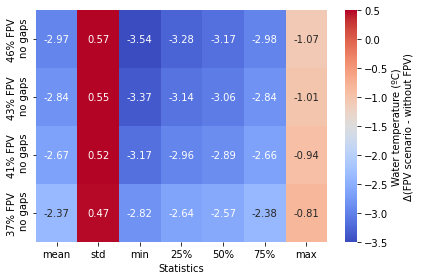

In [37]:
# Plot using seaborn heatmap for easy visual overview
plt.figure(figsize=(6, 4))
sns.heatmap(describe_01_t, annot = True, cmap = 'coolwarm', fmt = ".2f", 
            vmin = -3.5, vmax = 0.5,
            cbar = True, cbar_kws={'label': u'Water temperature (ºC)\nΔ(FPV scenario - without FPV)'} )

plt.ylabel('')
plt.xlabel('Statistics')
plt.tight_layout()
# plt.savefig('FPV01_arrayperim_describe_heatmap.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

In [38]:
# FPV 02
spring_summer = FPV_deltaWT_avdepth_season[(FPV_deltaWT_avdepth_season['season'] == 'spring') | 
                                           (FPV_deltaWT_avdepth_season['season'] == 'summer')]

describe_02 = spring_summer.describe()
describe_02 =describe_02[['delta_real_nogaps', 
                          'delta_real_cov43nogaps', 'delta_real_cov05_10x10',
                          'delta_real_cov41nogap', 'delta_real_cov10_10x10',
                          'delta_real_cov37nogap', 'delta_real_cov20_10x10']]

describe_02.columns = ['46% FPV\nno gaps', 
                       '43% FPV\nno gaps', '43% FPV\n5% gaps\n10x10m', 
                       '41% FPV\nno gaps', '41% FPV\n10% gaps\n10x10m', 
                       '37% FPV\nno gaps', '37% FPV\n20% gaps\n10x10m']

describe_02_t = describe_02.T
describe_02_t = describe_02_t[describe_02_t.columns[1:]]

describe_02

,46% FPV\nno gaps,43% FPV\nno gaps,43% FPV\n5% gaps\n10x10m,41% FPV\nno gaps,41% FPV\n10% gaps\n10x10m,37% FPV\nno gaps,37% FPV\n20% gaps\n10x10m
count,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000
mean,-2.968004,-2.837304,-2.783991,-2.666172,-2.644398,-2.373408,-2.406240
std,0.571463,0.551626,0.541432,0.522064,0.518952,0.470189,0.475711
min,-3.544452,-3.374701,-3.323751,-3.165830,-3.144808,-2.817471,-2.862893
25%,-3.279212,-3.140148,-3.076845,-2.956497,-2.934085,-2.639193,-2.669086
50%,-3.168822,-3.056294,-2.989269,-2.887081,-2.861838,-2.567677,-2.607780
75%,-2.984173,-2.835648,-2.788800,-2.657068,-2.636372,-2.379128,-2.401083
max,-1.071074,-1.008791,-0.993487,-0.936929,-0.925814,-0.813178,-0.828017


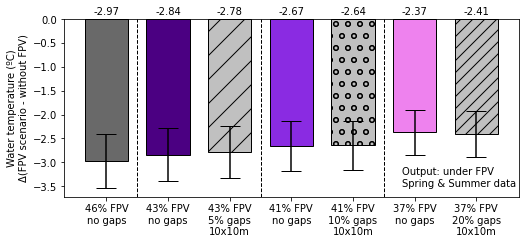

In [40]:
# Get mean and std
means = describe_02.loc['mean']
stds = describe_02.loc['std']

# Define your custom colors
custom_colors = {
    '46% FPV\nno gaps': 'dimgray',
    '43% FPV\nno gaps': 'indigo',
    '43% FPV\n5% gaps\n10x10m': 'silver',
    '41% FPV\nno gaps': 'blueviolet',
    '41% FPV\n10% gaps\n10x10m': 'silver',
    '37% FPV\nno gaps': 'violet',
    '37% FPV\n20% gaps\n10x10m': 'silver'
}

custom_hatches = {
    '46% FPV\nno gaps': '',
    '43% FPV\nno gaps': '',
    '43% FPV\n5% gaps\n10x10m': '/',
    '41% FPV\nno gaps': '',
    '41% FPV\n10% gaps\n10x10m': 'o',
    '37% FPV\nno gaps': '',
    '37% FPV\n20% gaps\n10x10m': '//'
}

# Extract the colors in the same order as the columns
colors = [custom_colors[col] for col in means.index]

# Plot
fig, ax = plt.subplots(figsize=(7.5, 3.5))

bars = ax.bar(
    means.index,
    means.values,
    yerr=stds.values,
    capsize=10,
    color=[custom_colors[col] for col in means.index],
    edgecolor='black',
    width = 0.7
)

# Apply hatches and add value labels
for bar, col in zip(bars, means.index):
    bar.set_hatch(custom_hatches[col])

    # Add text on top of the bar
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # center of the bar
        0.05,             # just above error bar
        f'{height:.2f}',                    # formatted mean
        ha='center', va='bottom', fontsize=10
    )

ax.text(4.8, -3.5, 'Output: under FPV\nSpring & Summer data', color = 'k', fontsize = 10)
    
plt.axvline(x = 0.5, color='k', linestyle='--', linewidth=1)
plt.axvline(x = 2.5, color='k', linestyle='--', linewidth=1)
plt.axvline(x = 4.5, color='k', linestyle='--', linewidth=1)

# Add labels and title
plt.ylabel(u'Water temperature (ºC)\nΔ(FPV scenario - without FPV)')
plt.tight_layout()
# plt.savefig('FPV02_arrayperim_describe_barplot.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

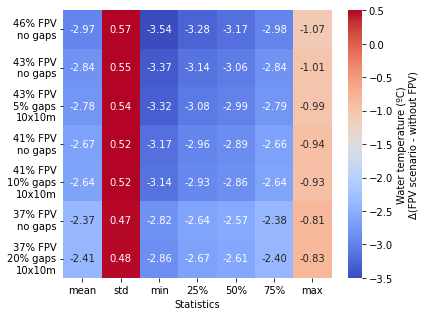

In [42]:
# Plot using seaborn heatmap for easy visual overview
plt.figure(figsize=(6, 4.5))
sns.heatmap(describe_02_t, annot = True, cmap = 'coolwarm', fmt = ".2f", 
            vmin = -3.5, vmax = 0.5,
            cbar = True, cbar_kws={'label': u'Water temperature (ºC)\nΔ(FPV scenario - without FPV)'} )

plt.ylabel('')
plt.xlabel('Statistics')
plt.tight_layout()
# plt.savefig('FPV02_arrayperim_describe_heatmap.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

In [43]:
# FPV 03
spring_summer = FPV_deltaWT_avdepth_season[(FPV_deltaWT_avdepth_season['season'] == 'spring') | 
                                           (FPV_deltaWT_avdepth_season['season'] == 'summer')]

describe_03 = spring_summer.describe()
describe_03 = describe_03[['delta_real_cov41nogap', 'delta_real_cov10_10x10',
                           'delta_real_cov10_10x20', 'delta_real_cov10_20x20', 'delta_real_DONUT_notransition']]

describe_03.columns = ['41% FPV\nno gaps', '41% FPV\n10% gaps\n10x10m', 
                       '41% FPV\n10% gaps\n10x20m', '41% FPV\n10% gaps\n20x20m', '41% FPV\n10% gaps\n80x80m']

describe_03_t = describe_03.T
describe_03_t = describe_03_t[describe_03_t.columns[1:]]

describe_03

,41% FPV\nno gaps,41% FPV\n10% gaps\n10x10m,41% FPV\n10% gaps\n10x20m,41% FPV\n10% gaps\n20x20m,41% FPV\n10% gaps\n80x80m
count,738.000000,738.000000,738.000000,738.000000,738.000000
mean,-2.666172,-2.644398,-2.688146,-2.662315,-2.652157
std,0.522064,0.518952,0.526643,0.521093,0.517158
min,-3.165830,-3.144808,-3.198598,-3.169572,-3.167596
25%,-2.956497,-2.934085,-2.980054,-2.951693,-2.936211
50%,-2.887081,-2.861838,-2.906757,-2.878297,-2.861680
75%,-2.657068,-2.636372,-2.681149,-2.655588,-2.650354
max,-0.936929,-0.925814,-0.946774,-0.938741,-0.936615


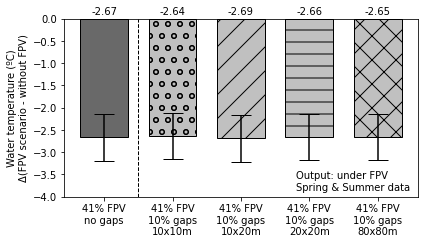

In [44]:
# Get mean and std
means = describe_03.loc['mean']
stds = describe_03.loc['std']

# Define your custom colors
custom_colors = {
    '41% FPV\nno gaps': 'dimgray',
    '41% FPV\n10% gaps\n10x10m': 'silver',
    '41% FPV\n10% gaps\n10x20m': 'silver',
    '41% FPV\n10% gaps\n20x20m': 'silver',
    '41% FPV\n10% gaps\n80x80m': 'silver'
}

custom_hatches = {
    '41% FPV\nno gaps': '',
    '41% FPV\n10% gaps\n10x10m': 'o',
    '41% FPV\n10% gaps\n10x20m': '/',
    '41% FPV\n10% gaps\n20x20m': '-',
    '41% FPV\n10% gaps\n80x80m': 'x'
}

# Extract the colors in the same order as the columns
colors = [custom_colors[col] for col in means.index]

# Plot
fig, ax = plt.subplots(figsize=(6, 3.5))

bars = ax.bar(
    means.index,
    means.values,
    yerr=stds.values,
    capsize=10,
    color=[custom_colors[col] for col in means.index],
    edgecolor='black', 
    width = 0.7
)

# Apply hatches and add value labels
for bar, col in zip(bars, means.index):
    bar.set_hatch(custom_hatches[col])

    # Add text on top of the bar
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # center of the bar
        0.05,             # just above error bar
        f'{height:.2f}',                    # formatted mean
        ha='center', va='bottom', fontsize=10
    )

ax.text(2.8, -3.85, 'Output: under FPV\nSpring & Summer data', color = 'k', fontsize = 10)
ax.set_ylim(-4, 0)
    
plt.axvline(x = 0.5, color='k', linestyle='--', linewidth=1)

# Add labels and title
plt.ylabel(u'Water temperature (ºC)\nΔ(FPV scenario - without FPV)')
plt.tight_layout()
# plt.savefig('FPV03_arrayperim_describe_barplot.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

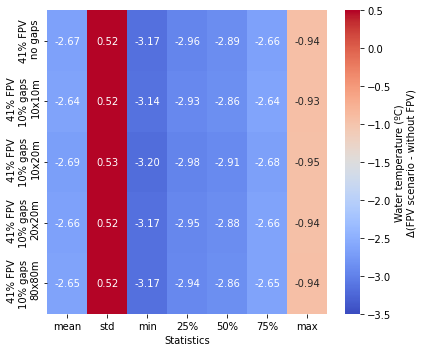

In [45]:
# Plot using seaborn heatmap for easy visual overview
plt.figure(figsize=(6, 5))
sns.heatmap(describe_03_t, annot = True, cmap = 'coolwarm', fmt = ".2f", 
            vmin = -3.5, vmax = 0.5,
            cbar = True, cbar_kws={'label': u'Water temperature (ºC)\nΔ(FPV scenario - without FPV)'} )

plt.ylabel('')
plt.xlabel('Statistics')
plt.tight_layout()
# plt.savefig('FPV03_arrayperim_describe_heatmap.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

# % coverage x deltaT

In [49]:
cover_deltaT = describe_01_t.copy()
cover_deltaT.reset_index(drop = False, inplace = True, names = 'scenario')
cover_deltaT['coverage'] = [0.46, 0.43, 0.41, 0.37]

cover_deltaT_surf = describe_surf_01_t.copy()
cover_deltaT_surf.reset_index(drop = False, inplace = True, names = 'scenario')
cover_deltaT_surf['coverage'] = [0.46, 0.43, 0.41, 0.37]

cover_deltaT_surf

,scenario,mean,std,min,25%,50%,75%,max,coverage
0,46% FPV\nno gaps,-1.458799,0.420325,-2.767375,-1.686463,-1.451532,-1.259095,0.004955,0.46
1,43% FPV\nno gaps,-1.385795,0.399669,-2.569633,-1.606300,-1.373969,-1.197265,0.004202,0.43
2,41% FPV\nno gaps,-1.300449,0.375750,-2.407727,-1.510593,-1.290755,-1.125576,0.003971,0.41
3,37% FPV\nno gaps,-1.152556,0.332491,-2.086556,-1.341142,-1.140518,-0.997159,0.003429,0.37


In [50]:
cover_deltaT_surf[['mean', 'coverage']]

,mean,coverage
0,-1.458799,0.46
1,-1.385795,0.43
2,-1.300449,0.41
3,-1.152556,0.37


In [53]:
# -------- AVERAGED DEPTH ---------
coverage  = np.array(cover_deltaT['coverage'])
mean  = np.array(cover_deltaT['mean'])

# -------- LINEAR FIT --------
linear_coeffs = np.polyfit(coverage, mean, 1)
linear_model = np.poly1d(linear_coeffs)
mean_pred_linear = linear_model(coverage)

# R² for linear
ss_res_linear = np.sum((mean - mean_pred_linear) ** 2)
ss_tot = np.sum((mean - np.mean(mean)) ** 2)
r2_linear = 1 - (ss_res_linear / ss_tot)

# Equation
linear_eq = f"y = {linear_coeffs[0]:.2f}x + {linear_coeffs[1]:.2f}"

# -------- EXPONENTIAL FIT --------
def exp_func(x, a, b, c):
    """Builds a custom exponential model to fit the data
    Try to find the best values of a, b, and c such that this exponential equation best fits the data"""
    return a * np.exp(b * x) + c

params, _ = curve_fit(exp_func, coverage, mean, p0=(1, 1, -3), maxfev=10000)
mean_pred_exp = exp_func(coverage, *params)

# R² for exponential
ss_res_exp = np.sum((mean - mean_pred_exp) ** 2)
r2_exp = 1 - (ss_res_exp / ss_tot)

# Equation
a, b, c = params
exp_eq = f"y = {a:.2f} * exp({b:.2f} * x) + {c:.2f}"

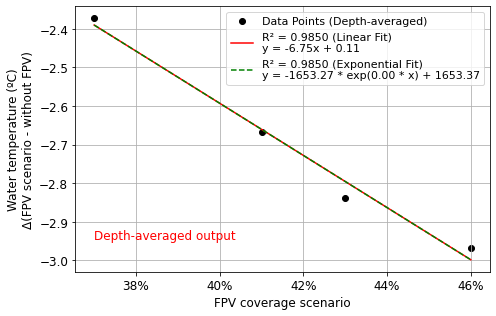

In [54]:
# -------- PLOTTING --------
x_fit = np.linspace(min(coverage), max(coverage), 200) # generates evenly distributed values of % coverage 
y_linear_fit = linear_model(x_fit) # calculates the predicted mean values using the linear model
y_exp_fit = exp_func(x_fit, *params) # calculates the predicted mean values using the exponential model - evaluate the fitted curve on smooth data

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.scatter(coverage, mean, color = 'black', label = 'Data Points (Depth-averaged)')

ax.plot(x_fit, y_linear_fit, color='red', label = f'R² = {r2_linear:.4f} (Linear Fit)\n{linear_eq}') # linear model
ax.plot(x_fit, y_exp_fit, color='green', linestyle='--', label=f'R² = {r2_exp:.4f} (Exponential Fit)\n{exp_eq}') # exponential 

# Format x-axis labels as percentages
formatter = FuncFormatter(lambda x, pos: f'{x * 100:.0f}%')  # Multiply by 100 to convert to percentage
plt.gca().xaxis.set_major_formatter(formatter)

ax.set_xlabel('FPV coverage scenario', fontsize = 12)
ax.set_ylabel(u'Water temperature (ºC)\nΔ(FPV scenario - without FPV)', fontsize = 12)

ax.text(0.37, -2.945, 'Depth-averaged output', fontsize = 12, color = 'r')

# Adjust tick label font sizes
ax.tick_params(axis='x', labelsize=12)  # x-axis tick labels
ax.tick_params(axis='y', labelsize=12)  # y-axis tick labels

ax.legend(loc = 'upper right', fontsize = 11)
ax.grid(True)

plt.tight_layout()
# plt.savefig('FPV01_WTxcoverage_depthavWT.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

In [55]:
print(f"Exponential model parameters: a={a}, b={b}, c={c}") # b is close to zero therefore behaves like a constant function

Exponential model parameters: a=-1653.2657858954587, b=0.004078289403846511, c=1653.3719687739715


In [56]:
# -------- SURFACE LAYER ---------
coverage  = np.array(cover_deltaT_surf['coverage'])
mean  = np.array(cover_deltaT_surf['mean'])

# -------- LINEAR FIT --------
linear_coeffs = np.polyfit(coverage, mean, 1)
linear_model = np.poly1d(linear_coeffs)
mean_pred_linear = linear_model(coverage)

# R² for linear
ss_res_linear = np.sum((mean - mean_pred_linear) ** 2)
ss_tot = np.sum((mean - np.mean(mean)) ** 2)
r2_linear = 1 - (ss_res_linear / ss_tot)

# Equation
linear_eq = f"y = {linear_coeffs[0]:.2f}x + {linear_coeffs[1]:.2f}"

# -------- EXPONENTIAL FIT --------
def exp_func(x, a, b, c):
    """Builds a custom exponential model to fit the data
    Try to find the best values of a, b, and c such that this exponential equation best fits the data"""
    return a * np.exp(b * x) + c

params, _ = curve_fit(exp_func, coverage, mean, p0=(1, 1, -3), maxfev=10000)
mean_pred_exp = exp_func(coverage, *params)

# R² for exponential
ss_res_exp = np.sum((mean - mean_pred_exp) ** 2)
r2_exp = 1 - (ss_res_exp / ss_tot)

# Equation
a, b, c = params
exp_eq = f"y = {a:.2f} * exp({b:.2f} * x) + {c:.2f}"

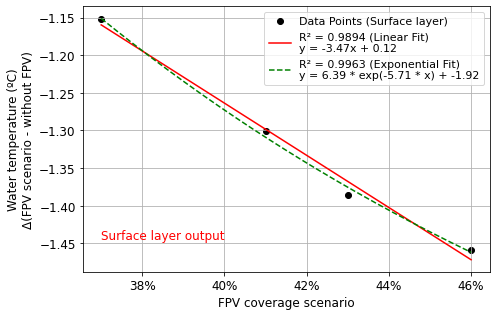

In [57]:
# -------- PLOTTING SURFACE LAYER --------
x_fit = np.linspace(min(coverage), max(coverage), 200) # generates evenly distributed values of % coverage 
y_linear_fit = linear_model(x_fit) # calculates the predicted mean values using the linear model
y_exp_fit = exp_func(x_fit, *params) # calculates the predicted mean values using the exponential model - evaluate the fitted curve on smooth data

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.scatter(coverage, mean, color = 'black', label = 'Data Points (Surface layer)')

ax.plot(x_fit, y_linear_fit, color='red', label = f'R² = {r2_linear:.4f} (Linear Fit)\n{linear_eq}') # linear model
ax.plot(x_fit, y_exp_fit, color='green', linestyle='--', label=f'R² = {r2_exp:.4f} (Exponential Fit)\n{exp_eq}') # exponential 

# Format x-axis labels as percentages
formatter = FuncFormatter(lambda x, pos: f'{x * 100:.0f}%')  # Multiply by 100 to convert to percentage
plt.gca().xaxis.set_major_formatter(formatter)

ax.set_xlabel('FPV coverage scenario', fontsize = 12)
ax.set_ylabel(u'Water temperature (ºC)\nΔ(FPV scenario - without FPV)', fontsize = 12)

ax.text(0.37, -1.445, 'Surface layer output', fontsize = 12, color = 'r')

# Adjust tick label font sizes
ax.tick_params(axis='x', labelsize=12)  # x-axis tick labels
ax.tick_params(axis='y', labelsize=12)  # y-axis tick labels

ax.legend(loc = 'upper right', fontsize = 11)
ax.grid(True)

plt.tight_layout()
# plt.savefig('FPV01_WTxcoverage_surfaceWT.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

In [58]:
print(f"Exponential model parameters: a={a}, b={b}, c={c}") # b is close to zero therefore behaves like a constant function

Exponential model parameters: a=6.394386994073152, b=-5.709987528762564, c=-1.9243468970243405


# Plots

Time series of water temperature

In [31]:
list(FPV_WT_depths_dic.keys())

['real_DONUT_notransition',
 'real_cov05_10x10',
 'real_cov10_10x10',
 'real_cov10_10x20',
 'real_cov10_20x20',
 'real_cov20_10x10',
 'real_cov37nogap',
 'real_cov41nogap',
 'real_cov43nogaps',
 'real_nogaps',
 'dation_fulldata_spatialmeteo']

<ipython-input-101-f61a877e4442>:42: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels_new)


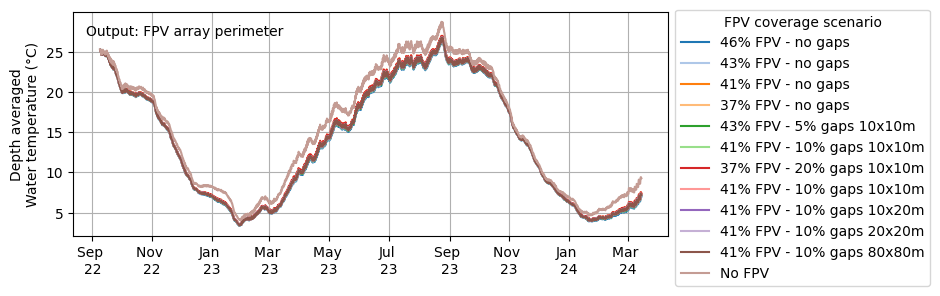

In [101]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9.5,3], sharex = True, sharey = True)
pal = sns.color_palette("tab20", 20)

# scenarios = ['real_cov05_10x10', 'real_DONUT_notransition', 'real_cov10_10x10', 'real_cov10_10x20', 'real_cov10_20x20',
#              'real_cov20_10x10', 'real_cov37nogap', 'real_cov41nogap', 'real_cov43nogaps', 'real_nogaps',
#              'dation_fulldata_spatialmeteo']

scenarios = ['real_nogaps', 'real_cov43nogaps', 'real_cov41nogap', 'real_cov37nogap', 
             'real_cov05_10x10', 'real_cov10_10x10', 'real_cov20_10x10', 
             'real_cov10_10x10', 'real_cov10_10x20', 'real_cov10_20x20', 'real_DONUT_notransition', 
             'dation_fulldata_spatialmeteo']

# labels = ['37%', '41%', '43%', '46%', 'No FPV']

# labels = ['41% FPV - 80x80m', '41% FPV - 10x10m', 
#           '41% FPV - 10x20m', '41% FPV - 20x20m', 'No FPV']

# labels = ['43% FPV - 5% gaps', '43% FPV - no gaps', 
#           '41% FPV - 10% gaps', '41% FPV - no gaps',
#           '37% FPV - 20% gaps', '37% FPV - no gaps', 'No FPV']

# labels = ['43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 80x80m', '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m',
#           '41% FPV - 10% gaps 20x20m', '37% FPV - 20% gaps 10x10m', '37% FPV - no gaps', '41% FPV - no gaps',
#           '43% FPV - no gaps', '46% FPV - no gaps', 'No FPV']

labels = ['46% FPV - no gaps', '43% FPV - no gaps', '41% FPV - no gaps', '37% FPV - no gaps', 
          '43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 10x10m', '37% FPV - 20% gaps 10x10m', 
          '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m', '41% FPV - 10% gaps 80x80m', 
          'No FPV']

for scen in range(len(scenarios)):
    temp = FPV_WT_depths_dic[scenarios[scen]].copy()

    ax.plot(temp.index, temp[temp.columns[-1]], color = pal.as_hex()[scen], linestyle='-', 
            label = (labels[scen]))

ax.grid(True)

xlabels = ['Sep 22', 'Nov 22', 'Jan 23', 'Mar 23', 'May 23', 'Jul 23', 'Sep 23', 'Nov 23', 'Jan 24', 'Mar 24']
xlabels_new = [re.sub("(.{4})", "\\1\n", label, 0, re.DOTALL) for label in xlabels]
ax.set_xticklabels(xlabels_new)
ax.text(19230, 27, 'Output: FPV array perimeter', color = 'k', fontsize = 10)

# ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1)

ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1, bbox_to_anchor=(1, 1.04))

ax.yaxis.set_label_text(u'Depth averaged\nWater temperature (°C)')

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPVall_arrayperim_scen_depthaveraged_WT_timeseries.jpeg', dpi=300, bbox_inches='tight')

plt.show();

In [35]:
FPV_deltaWT_avdepth.columns

Index(['delta_real_DONUT_notransition', 'delta_real_cov05_10x10',
       'delta_real_cov10_10x10', 'delta_real_cov10_10x20',
       'delta_real_cov10_20x20', 'delta_real_cov20_10x10',
       'delta_real_cov37nogap', 'delta_real_cov41nogap',
       'delta_real_cov43nogaps', 'delta_real_nogaps'],
      dtype='object')

<ipython-input-103-441912b563e3>:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels_new)


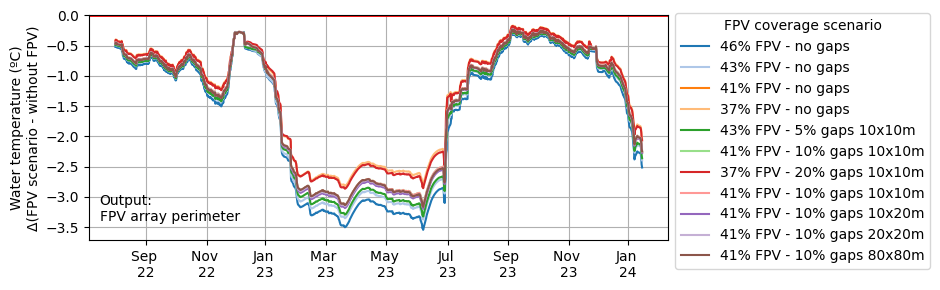

In [103]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9.5,3], sharex = True, sharey = True)
pal = sns.color_palette("tab20", 20)

plot_number = 9
# scenarios = FPV_deltaWT_avdepth.columns

# scenarios = ['delta_PV_real_cov05_10x10',
#              'delta_PV_real_cov43nogaps',
#              'delta_PV_real_cov10_10x10',
#              'delta_PV_real_cov41nogap',
#              'delta_PV_real_cov20_10x10',
#              'delta_PV_real_cov37nogap']

# labels = ['43% FPV - 5% gaps', '43% FPV - no gaps', 
#           '41% FPV - 10% gaps', '41% FPV - no gaps',
#           '37% FPV - 20% gaps', '37% FPV - no gaps']

# scenarios = ['delta__real_DONUT_notransition', 'delta__real_cov10_10x10',
#              'delta__real_cov10_10x20', 'delta__real_cov10_20x20']

scenarios = ['delta_real_nogaps', 'delta_real_cov43nogaps', 'delta_real_cov41nogap', 'delta_real_cov37nogap', 
             'delta_real_cov05_10x10', 'delta_real_cov10_10x10', 'delta_real_cov20_10x10', 
             'delta_real_cov10_10x10', 'delta_real_cov10_10x20', 'delta_real_cov10_20x20', 'delta_real_DONUT_notransition']

labels = ['46% FPV - no gaps', '43% FPV - no gaps', '41% FPV - no gaps', '37% FPV - no gaps', 
          '43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 10x10m', '37% FPV - 20% gaps 10x10m', 
          '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m', '41% FPV - 10% gaps 80x80m']

# labels = ['37%', '41%', '43%', '46%']

# labels = ['41% FPV - 80x80m', '41% FPV - 10x10m', 
#           '41% FPV - 10x20m', '41% FPV - 20x20m']

for scen in range(len(scenarios)):
    ax.plot(FPV_deltaWT_avdepth.index, FPV_deltaWT_avdepth[scenarios[scen]], 
            color = pal.as_hex()[scen], linestyle='-', label = (labels[scen]))

ax.grid(True)

xlabels = ['Sep 22', 'Nov 22', 'Jan 23', 'Mar 23', 'May 23', 'Jul 23', 'Sep 23', 'Nov 23', 'Jan 24', 'Mar 24']
xlabels_new = [re.sub("(.{4})", "\\1\n", label, 0, re.DOTALL) for label in xlabels]
ax.set_xticklabels(xlabels_new)

plt.axhline(y = 0, color='r', linestyle='-', linewidth = 2)

ax.text(19250, -3.4, 'Output:\nFPV array perimeter', color = 'k', fontsize = 10)

# ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1)

ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1, bbox_to_anchor=(1, 1.04))

ax.yaxis.set_label_text(u'Water temperature (ºC)\nΔ(FPV scenario - without FPV)')

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPVall_arrayperim_scen_depthaveraged_deltaWT_timeseries.jpeg', dpi=300, bbox_inches='tight')

plt.show();

In [145]:
bp_deltaWT_comp_av.scenario.unique()

array(['41% FPV - 80x80m', '41% FPV - 10x10m', '41% FPV - 10x20m',
       '41% FPV - 20x20m'], dtype=object)

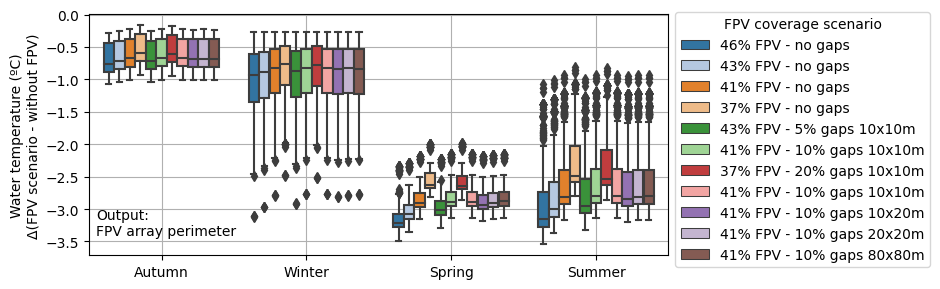

In [105]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9.5,3], sharex = True, sharey = True)
pal = sns.color_palette("tab20", 15)

# my_order = ['37%', '41%', '43%', '46%']

# my_order = ['41% FPV - 80x80m', '41% FPV - 10x10m', '41% FPV - 10x20m', '41% FPV - 20x20m']

my_order = ['46% FPV - no gaps', '43% FPV - no gaps', '41% FPV - no gaps', '37% FPV - no gaps', 
            '43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 10x10m', '37% FPV - 20% gaps 10x10m', 
            '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m', '41% FPV - 10% gaps 80x80m']

# my_order = ['43% FPV - 5% gaps', '43% FPV - no gaps', 
#             '41% FPV - 10% gaps', '41% FPV - no gaps',
#             '37% FPV - 20% gaps', '37% FPV - no gaps']

sns.boxplot(x = "season", y = "depth_averaged_deltaWT", 
            data = bp_deltaWT_comp_av[:-1],
            width = 0.8, boxprops = {'zorder': 2}, palette = pal[0:15], ax = ax, 
            order = ['autumn', 'winter', 'spring', 'summer'],
            hue = 'scenario', hue_order = my_order)

ax.grid(True)

# ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
#                frameon = True, columnspacing = 1)

ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
               frameon = True, columnspacing = 1, bbox_to_anchor=(1, 1.04))

ax.yaxis.set_label_text(u'Water temperature (ºC)\nΔ(FPV scenario - without FPV)', fontsize = 10)
ax.xaxis.set_label_text(u'', fontsize = 10)

ax.set_xticklabels(['Autumn', 'Winter', 'Spring', 'Summer'], fontsize=10)

ax.text(-0.45, -3.4, 'Output:\nFPV array perimeter', color = 'k', fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPVall_arrayperim_depthavWT_boxplot_season.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

In [ ]:
bp_deltaWT_comp_av_6am

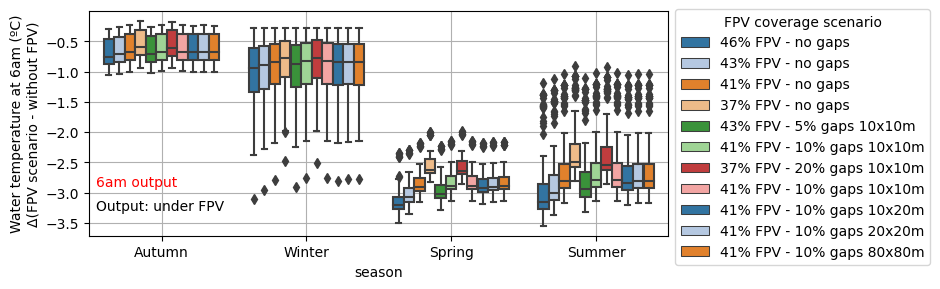

In [125]:
# Plot time series raw data for WT among scenarios - 18h output data
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9.5,3], sharex = True, sharey = True)
pal = sns.color_palette("tab20", 20)

# my_order = ['37%', '41%', '43%', '46%']

# my_order = ['41% FPV - 80x80m', '41% FPV - 10x10m', '41% FPV - 10x20m', '41% FPV - 20x20m']

# my_order = ['43% FPV - 5% gaps', '43% FPV - no gaps', 
#             '41% FPV - 10% gaps', '41% FPV - no gaps',
#             '37% FPV - 20% gaps', '37% FPV - no gaps']

my_order = ['46% FPV - no gaps', '43% FPV - no gaps', '41% FPV - no gaps', '37% FPV - no gaps', 
            '43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 10x10m', '37% FPV - 20% gaps 10x10m', 
            '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m', '41% FPV - 10% gaps 80x80m']

sns.boxplot(x = "season", y = "depth_averaged_deltaWT", 
            data = bp_deltaWT_comp_av_6am,
            width = 0.8, boxprops = {'zorder': 2}, palette = pal[0:8], ax = ax, 
            order = ['autumn', 'winter', 'spring', 'summer'],
            hue = 'scenario', hue_order = my_order)

ax.grid(True)

# ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
#                frameon = True, columnspacing = 1)

ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
               frameon = True, columnspacing = 1, bbox_to_anchor=(1, 1.04))

ax.yaxis.set_label_text(u'Water temperature at 6am (ºC)\nΔ(FPV scenario - without FPV)', fontsize = 10)
# ax.xaxis.set_label_text(u'Depth (m)', fontsize = 10)

ax.set_xticklabels(['Autumn', 'Winter', 'Spring', 'Summer'], fontsize=10)

ax.text(-0.45, -2.9, '6am output', color = 'r', fontsize = 10)
ax.text(-0.45, -3.3, 'Output: under FPV', color = 'k', fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPVall_arrayperim_depthavWT_6am_boxplot_season.jpeg', dpi = 300, bbox_inches='tight')

plt.show();

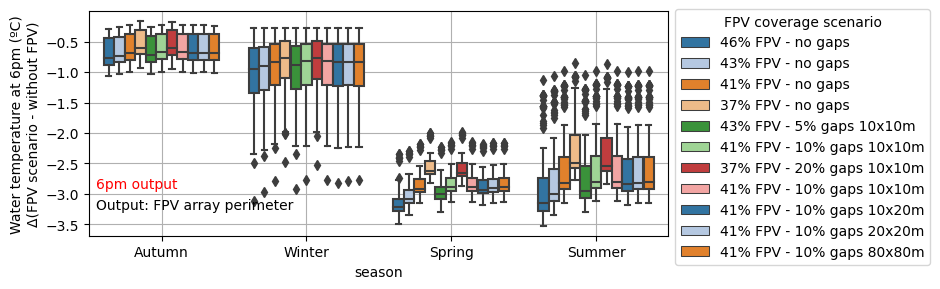

In [107]:
# Plot time series raw data for WT among scenarios - 18h output data
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9.5,3], sharex = True, sharey = True)
pal = sns.color_palette("tab20", 20)

# my_order = ['37%', '41%', '43%', '46%']

# my_order = ['41% FPV - 80x80m', '41% FPV - 10x10m', '41% FPV - 10x20m', '41% FPV - 20x20m']

# my_order = ['43% FPV - 5% gaps', '43% FPV - no gaps', 
#             '41% FPV - 10% gaps', '41% FPV - no gaps',
#             '37% FPV - 20% gaps', '37% FPV - no gaps']

my_order = ['46% FPV - no gaps', '43% FPV - no gaps', '41% FPV - no gaps', '37% FPV - no gaps', 
            '43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 10x10m', '37% FPV - 20% gaps 10x10m', 
            '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m', '41% FPV - 10% gaps 80x80m']

sns.boxplot(x = "season", y = "depth_averaged_deltaWT", 
            data = bp_deltaWT_comp_av_18h,
            width = 0.8, boxprops = {'zorder': 2}, palette = pal[0:8], ax = ax, 
            order = ['autumn', 'winter', 'spring', 'summer'],
            hue = 'scenario', hue_order = my_order)

ax.grid(True)

# ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
#                frameon = True, columnspacing = 1)

ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
               frameon = True, columnspacing = 1, bbox_to_anchor=(1, 1.04))

ax.yaxis.set_label_text(u'Water temperature at 6pm (ºC)\nΔ(FPV scenario - without FPV)', fontsize = 10)
# ax.xaxis.set_label_text(u'Depth (m)', fontsize = 10)

ax.set_xticklabels(['Autumn', 'Winter', 'Spring', 'Summer'], fontsize=10)

ax.text(-0.45, -2.9, '6pm output', color = 'r', fontsize = 10)
ax.text(-0.45, -3.25, 'Output: FPV array perimeter', color = 'k', fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPVall_arrayperim_depthavWT_18h_boxplot_season.jpeg', dpi=300, bbox_inches='tight')

plt.show();

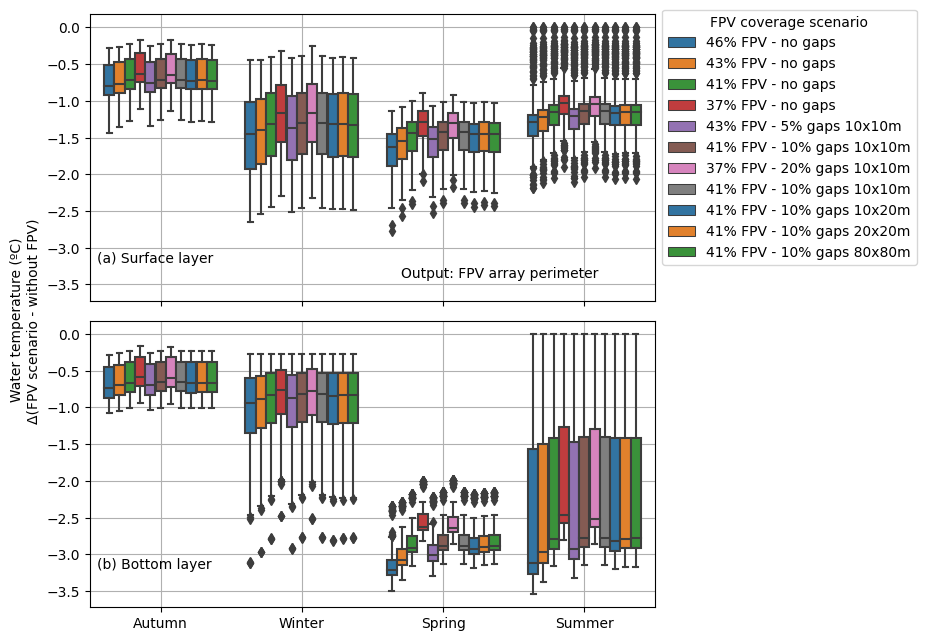

In [110]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = [9,6.5], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

sns.boxplot(x = "season", y = "surface_deltaWT", 
            data = bp_deltaWT_comp_surf,
            width = 0.8, boxprops = {'zorder': 2}, palette = pal[0:8], ax = ax[0], 
            order = ['autumn', 'winter', 'spring', 'summer'],
            hue = 'scenario', hue_order = my_order)

ax[0].grid(True)
# ax[0].legend(title = "FPV coverage scenario", ncol = 2, fontsize = 10, 
#              frameon = True, columnspacing = 1, loc = 'lower right')

ax[0].legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
             frameon = True, columnspacing = 1, bbox_to_anchor=(1, 1.04))

sns.boxplot(x = "season", y = "bottom_deltaWT", 
            data = bp_deltaWT_comp_bottom,
            width = 0.8, boxprops = {'zorder': 2}, palette = pal[0:8], ax = ax[1], 
            order = ['autumn', 'winter', 'spring', 'summer'],
            hue = 'scenario', hue_order = my_order)
ax[1].grid(True)
ax[1].get_legend().set_visible(False)

ax[0].text(1.7, -3.4, 'Output: FPV array perimeter', color = 'k', fontsize = 10)
ax[0].text(-0.45, -3.2, '(a) Surface layer', color = 'k', fontsize = 10)
ax[1].text(-0.45, -3.2, '(b) Bottom layer', color = 'k', fontsize = 10)

ax[0].yaxis.set_label_text('')
ax[1].yaxis.set_label_text('')
ax[0].xaxis.set_label_text('')
ax[1].xaxis.set_label_text('')
ax[1].set_xticklabels(['Autumn', 'Winter', 'Spring', 'Summer'], fontsize=10)

fig.text(-0.024, 0.5, u'     Water temperature (ºC)\nΔ(FPV scenario - without FPV)', va='center', rotation='vertical')

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPVall_arrayperim_scen_surfacexbottomWT_bp_depth.jpeg', dpi=300, bbox_inches='tight')

plt.show();

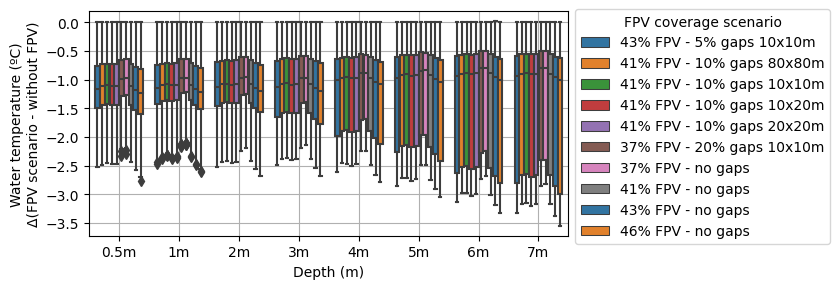

In [99]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [8.5,3], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

sns.boxplot(x = "depth", y = "deltaWT", 
            data = bp_deltaWT_comp_depths[bp_deltaWT_comp_depths['depth'] != 'delta_depthdepth_averaged_WT'],
            width = 0.8, boxprops = {'zorder': 2}, palette = pal[0:8], ax = ax, 
            hue = 'scenario', hue_order = my_order)
ax.set_xticklabels(['0.5m', '1m', '2m', '3m', '4m', '5m', '6m', '7m'], fontsize=10)
ax.grid(True)

# ax.legend(title = "FPV coverage scenario", ncol = 2, fontsize = 10, 
#                frameon = True, columnspacing = 1, loc = 'lower left')

ax.legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, 
               frameon = True, columnspacing = 1, bbox_to_anchor=(1, 1.04))

ax.yaxis.set_label_text(u'Water temperature (ºC)\nΔ(FPV scenario - without FPV)', fontsize = 10)
ax.xaxis.set_label_text(u'Depth (m)', fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV03_arrayperim_scen_WT_bp_depth.jpeg', dpi=300, bbox_inches='tight')

plt.show();

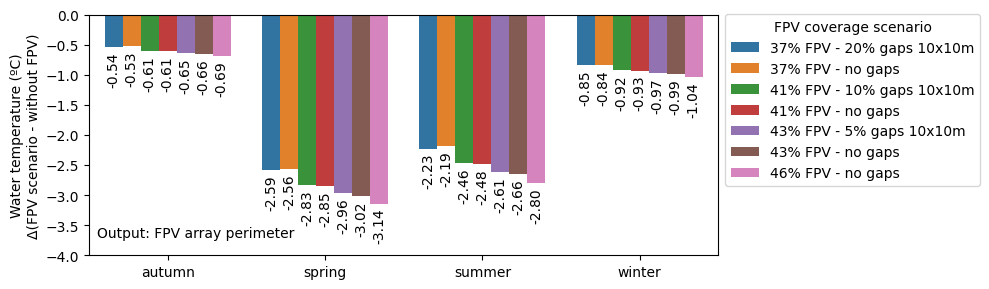

In [116]:
plot = bp_deltaWT_comp_av[(bp_deltaWT_comp_av['scenario'] == '43% FPV - 5% gaps 10x10m') | 
                          (bp_deltaWT_comp_av['scenario'] == '43% FPV - no gaps') | 
                          (bp_deltaWT_comp_av['scenario'] == '41% FPV - 10% gaps 10x10m') | 
                          (bp_deltaWT_comp_av['scenario'] == '41% FPV - no gaps') | 
                          (bp_deltaWT_comp_av['scenario'] == '37% FPV - 20% gaps 10x10m') | 
                          (bp_deltaWT_comp_av['scenario'] == '37% FPV - no gaps') | 
                          (bp_deltaWT_comp_av['scenario'] == '46% FPV - no gaps')]

# Aggregate data if needed (e.g., mean per scenario per month)
agg_df = plot.groupby(['scenario', 'season'], as_index=False)['depth_averaged_deltaWT'].mean()

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 3))
barplot = sns.barplot(
    data=agg_df,
    x='season',
    y='depth_averaged_deltaWT',
    hue='scenario', ax = ax
)

# Add rotated labels **above** bars
for container in barplot.containers:
    labels = barplot.bar_label(container, fmt='%.2f', padding=3)
    for label in labels:
        label.set_rotation(90)  # Rotate the label
        label.set_fontsize(10)

ax.set_ylim(-4,0)
ax.set_ylabel(u'Water temperature (ºC)\nΔ(FPV scenario - without FPV)')
ax.set_xlabel('')
ax.legend(title='FPV coverage scenario', bbox_to_anchor=(1, 1.03), loc='upper left')

ax.text(-0.45, -3.7, 'Output: FPV array perimeter', color = 'k', fontsize = 10)

fig.tight_layout()
# plt.savefig(path_figures + 'FPV02_arrayperim_barplot_deltaWT.jpeg', dpi=300, bbox_inches='tight')
plt.show();

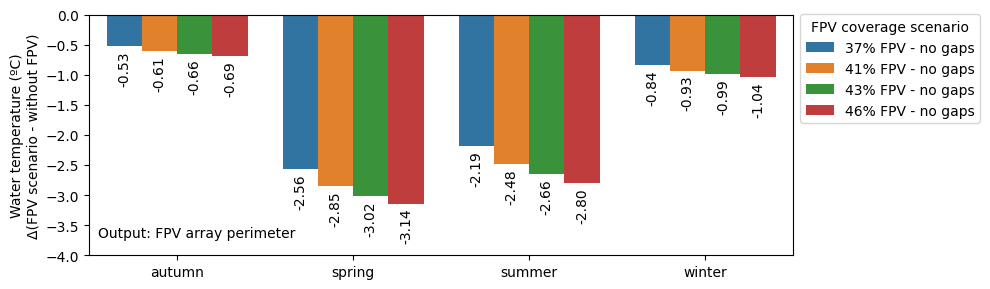

In [119]:
plot = bp_deltaWT_comp_av[(bp_deltaWT_comp_av['scenario'] == '46% FPV - no gaps') | 
                          (bp_deltaWT_comp_av['scenario'] == '43% FPV - no gaps') | 
                          (bp_deltaWT_comp_av['scenario'] == '41% FPV - no gaps') | 
                          (bp_deltaWT_comp_av['scenario'] == '37% FPV - no gaps')]

# Aggregate data if needed (e.g., mean per scenario per month)
agg_df = plot.groupby(['scenario', 'season'], as_index=False)['depth_averaged_deltaWT'].mean()

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 3))
barplot = sns.barplot(
    data=agg_df,
    x='season',
    y='depth_averaged_deltaWT',
    hue='scenario', ax = ax
)

# Add rotated labels **above** bars
for container in barplot.containers:
    labels = barplot.bar_label(container, fmt='%.2f', padding=3)
    for label in labels:
        label.set_rotation(90)  # Rotate the label
        label.set_fontsize(10)

ax.set_ylim(-4,0)
ax.set_ylabel(u'Water temperature (ºC)\nΔ(FPV scenario - without FPV)')
ax.set_xlabel('')
ax.legend(title='FPV coverage scenario', bbox_to_anchor=(1, 1.03), loc='upper left')

ax.text(-0.45, -3.7, 'Output: FPV array perimeter', color = 'k', fontsize = 10)

fig.tight_layout()
# plt.savefig(path_figures + 'FPV01_arrayperim_barplot_deltaWT.jpeg', dpi=300, bbox_inches='tight')
plt.show();

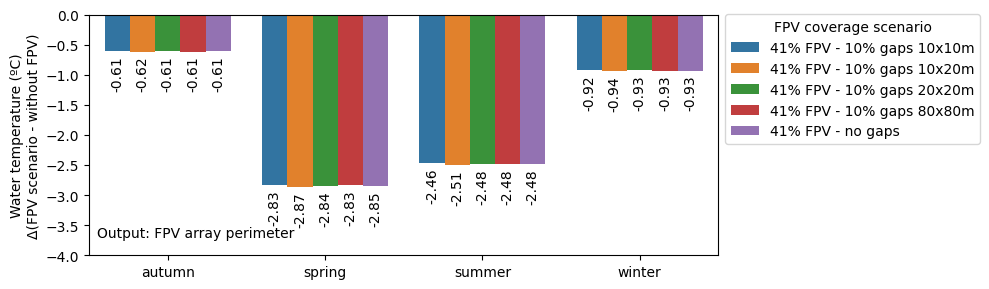

In [122]:
plot = bp_deltaWT_comp_av[(bp_deltaWT_comp_av['scenario'] == '41% FPV - no gaps') | 
                          (bp_deltaWT_comp_av['scenario'] == '41% FPV - 10% gaps 80x80m') | 
                          (bp_deltaWT_comp_av['scenario'] == '41% FPV - 10% gaps 10x10m') | 
                          (bp_deltaWT_comp_av['scenario'] == '41% FPV - 10% gaps 10x20m') | 
                          (bp_deltaWT_comp_av['scenario'] == '41% FPV - 10% gaps 20x20m')]

# Aggregate data if needed (e.g., mean per scenario per month)
agg_df = plot.groupby(['scenario', 'season'], as_index=False)['depth_averaged_deltaWT'].mean()

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 3))
barplot = sns.barplot(
    data=agg_df,
    x='season',
    y='depth_averaged_deltaWT',
    hue='scenario', ax = ax
)

# Add rotated labels **above** bars
for container in barplot.containers:
    labels = barplot.bar_label(container, fmt='%.2f', padding=3)
    for label in labels:
        label.set_rotation(90)  # Rotate the label
        label.set_fontsize(10)

ax.set_ylim(-4,0)
ax.set_ylabel(u'Water temperature (ºC)\nΔ(FPV scenario - without FPV)')
ax.set_xlabel('')
ax.legend(title='FPV coverage scenario', bbox_to_anchor=(1, 1.03), loc='upper left')

ax.text(-0.45, -3.7, 'Output: FPV array perimeter', color = 'k', fontsize = 10)

fig.tight_layout()
# plt.savefig(path_figures + 'FPV03_arrayperim_barplot_deltaWT.jpeg', dpi=300, bbox_inches='tight')
plt.show();